# Install Python libraries

Install the following Python libraries if not already available in the current kernel.
```bash
pip install matplotlib
pip install tensorflow
pip install scikit-learn
```

# Dataset Preparation

The data are read from all samples in the given folder (desktop applications). From the source JSON we extract only the following (numerical) features:

* Flow Data: A subset of columns that contain numerical flow metrics ('BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration') is extracted from the DataFrame. These values are converted to a NumPy array of type float32.
* TLS Records size sequence: The 'RecordSequence' column, which holds sequences (arrays) of integers is taken and the array is padded or truncated so that its length is exactly RECORD_SEQUENCE_SIZE (20). These values are converted to a NumPy array of type float32.

The processed numerical flow data and the padded record sequences are concatenated horizontally (column-wise) such that each row has exactly 25 columns. Any NaN values in the concatenated dataset are replaced with 0.

For each column in the dataset, the minimum and maximum values are computed. A min-max normalization is then applied column-wise. This rescales every value so that each feature (column) lies in the range [0,1].

`normalized_dataset` is prepared and can be used for the autoencoder training.

In [155]:
import json
import glob
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

RECORD_SEQUENCE_SIZE=20

# Match all JSON files in the 'data' directory
json_files = glob.glob("../datasets/desktop.joy/*.joy.json")

print(f'source files={len(json_files)}')
all_data = []
# Open the file and read each line
for filename in json_files:
    with open(filename, "r") as file:
        # Use a list comprehension to load each line as a JSON object
        data = [json.loads(line.strip()) for line in file]
        all_data.extend(data)
# Convert the list of dictionaries into a DataFrame
df = pd.DataFrame(all_data)
flow_cols = ['BytesOut', 'PacketsOut', 'BytesIn', 'PacketsIn', 'Duration']
flow_data = df[flow_cols].values.astype('float32')
records_data = pad_sequences(df['RecordSequence'].values, maxlen=RECORD_SEQUENCE_SIZE, padding='post',truncating='post')  
dataset = np.concatenate((flow_data,records_data), axis=1)
dataset = np.nan_to_num(dataset, nan=0)

# normalization values per column:
min_vals = dataset.min(axis=0)
max_vals = dataset.max(axis=0)
normalized_dataset = (dataset - min_vals) / (max_vals - min_vals)

print(f'dataset shape={normalized_dataset.shape}')

source files=1427
dataset shape=(14991, 25)


# Autoencoder Training

The autoencoder is trained on `normalized_dataset`. The data are split into training (80%) and testing (20%) parts. The size of laten space is set to `LATENT_SPACE_SIZE`.

The results are visualzied for the 10 selected sample. 

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

train shape=(11992, 25)
test shape=(2999, 25)
Epoch 1/50


47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6876 - val_loss: 0.6546
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6356 - val_loss: 0.5659
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5413 - val_loss: 0.4711
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4558 - val_loss: 0.4224
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4172 - val_loss: 0.4051
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4025 - val_loss: 0.3977
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3973 - val_loss: 0.3938
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3935 - val_loss: 0.3914
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3907 - val_loss: 0.3894
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3896 - val_loss: 0.3872
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3868 - val_loss: 0.3854
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3845 - val_loss: 0.3838


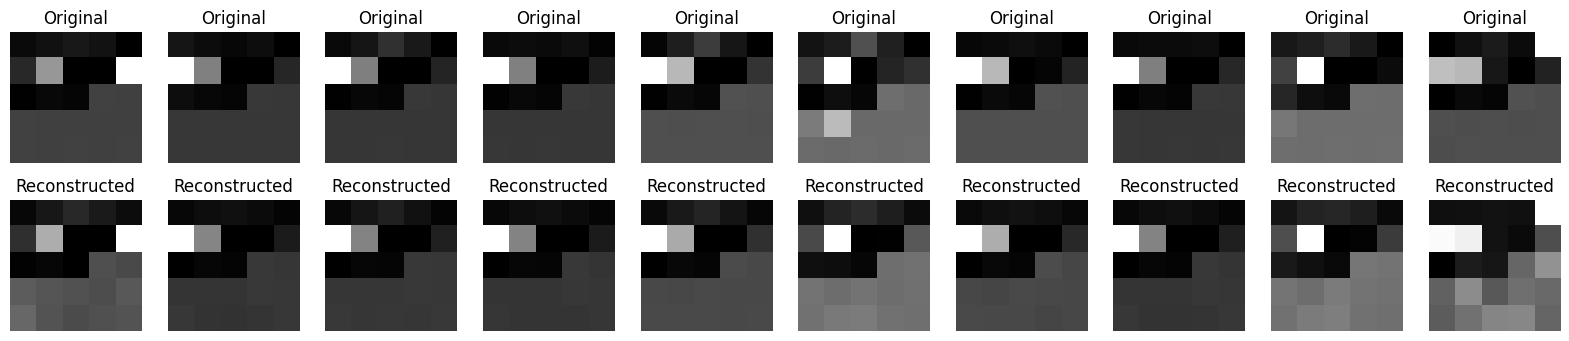

In [159]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
LATENT_SPACE_SIZE=8

# 1. Split data to traingin and testing
x_train, x_test = train_test_split(normalized_dataset, test_size=0.2)
print(f'train shape={x_train.shape}')
print(f'test shape={x_test.shape}')

# 2. Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Input placeholder
input_img = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model for later use
encoder = Model(input_img, encoded)

# Decoder model setup
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# 3. Compile and train the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# 4. Visualize the reconstructed images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Assuming x_test contains the original test data
# and decoded_imgs are the autoencoder's reconstructed outputs
reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

# Average reconstruction error across all samples
avg_error = np.mean(reconstruction_errors)

print("Reconstruction error for each sample:", reconstruction_errors)
print("Average reconstruction error:", avg_error)

n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    original = x_test[i]
    reconstructed = decoded_imgs[i]
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(original.reshape(5, 5), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed.reshape(5, 5), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


# Test with unknown data

TODO: Load ICSX dataset and test with autoencoder...